In [1]:
from helper_functions import *

# Problem 2: Question 14

In [3]:
auto_df = pd.read_csv('../Homework_Data/Auto.csv')

14.a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows:

In [4]:
auto_df['mpg01'] = auto_df['mpg'].apply(lambda x: 1 if x > auto_df['mpg'].median() else 0)

14b) Explore the data graphically in order to investigate the association between mpg01 and the other features. 

Which of the other features seem most likely to be useful in predicting mpg01? 

Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

In [25]:
auto_df['horsepower'] = auto_df['horsepower'].apply(lambda x: x if x != np.nan else x)

In [27]:
auto_df['horsepower'] = auto_df.horsepower.astype(float)

In [28]:
auto_df = auto_df.dropna()

In [29]:
auto_df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
mpg01             int64
dtype: object

In [10]:
import seaborn as sb

In [31]:
 auto_df.columns[:-1]

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin', 'name'],
      dtype='object')

In [32]:
feature_columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin']

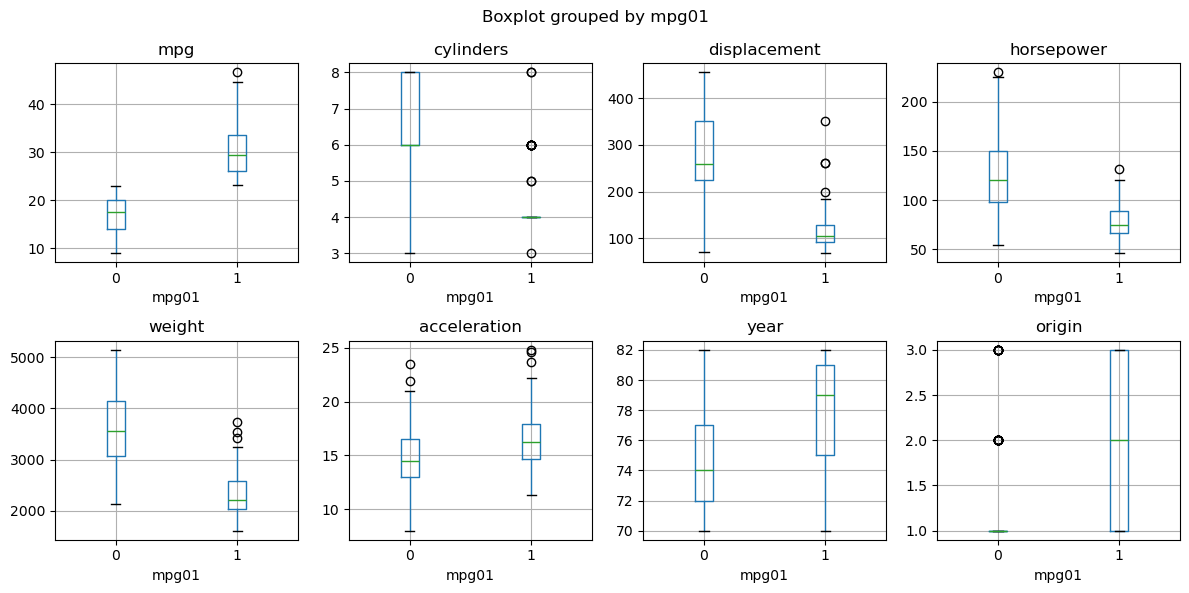

In [35]:
fig, axes = plt.subplots(2, 4, figsize = (12, 6))

ax = axes.flatten()

for a, col in zip(ax, feature_columns):
    auto_df.boxplot(column=col, by='mpg01', ax = a)

plt.tight_layout()

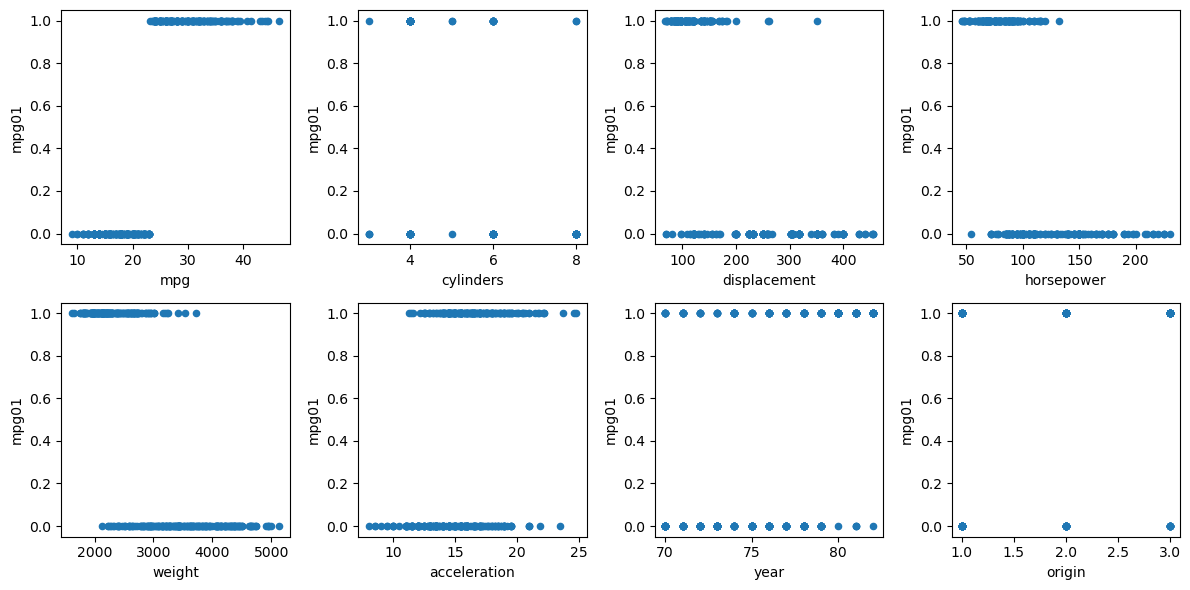

In [42]:
fig, axes = plt.subplots(2, 4, figsize = (12, 6))

ax = axes.flatten()

for a, col in zip(ax, feature_columns):
    auto_df.plot(kind = 'scatter', x=col, y='mpg01', ax = a)

plt.tight_layout()

From the Boxplots I can see that that mpg seems to be a good predictor as there is little overlap bwtween the IQR of the two distirbutions in mpg01, Displacement also seems to be another one that has this difference pretty evident as well. Weight is also one feature that shows stark difference in the two distributions. Horsepower also seems to show hints of being different between the mpg01 cataegory and could be used but we need more tests to confirm. All the other ones seems to have lots of overlap between being above or below the median and so are not clear predictors for mpg01. 

14c) Split the data into a training set and a test set.

In [81]:
from sklearn.model_selection import train_test_split

X = auto_df[feature_columns]
y = auto_df['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.75, random_state = 0)

14f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). 

What is the test error of the model obtained?

In [65]:
good_features = ['mpg', 'displacement', 'horsepower', 'weight']

In [66]:
reduced_auto = auto_df[good_features]

In [ ]:
design = MS(good_features)

X = design.fit_transform(X_train)

glm = sm.GLM(y_train, 
             X,
             family=sm.families.Binomial())

results = glm.fit()

summarize(results)

/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/oac466/anaconda3/envs/islp/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


,coef,std err,z,P>|z|
intercept,-1153.8824,707000.000,-0.002000,0.999
mpg,47.3201,27500.000,0.002000,0.999
displacement,0.2851,2530.220,0.000000,1.000
horsepower,0.4712,1875.142,0.000000,1.000
weight,-0.0137,284.701,-0.000048,1.000


In [103]:
design = MS(good_features)

X_t = design.fit_transform(X_test)
probs = results.predict(X_t)

In [104]:
labels = np.zeros(X_test.shape[0])
labels[probs >0.5] = 1

In [105]:
confusion_table(labels , y_test)

Truth,0,1
Predicted,,
0,157,0
1,1,136


14h) Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). 

What test errors do you obtain?

Which value of K seems to perform the best on this data set?

In [107]:
from sklearn. neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score, recall_score, precision_score

In [108]:
n = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]

test_errors = []

for k in n:

    knn1 = KNeighborsClassifier (n_neighbors =k)
    knn1.fit(X_train[good_features], y_train)
    knn1_pred = knn1.predict(X_test[good_features])

    acc = accuracy_score(knn1_pred, y_test)
    f1 = f1_score(knn1_pred, y_test)
    recall = recall_score(knn1_pred, y_test)
    precision = precision_score(knn1_pred, y_test)

    print(f'k = {k} \n Accuracy: {acc} \n F1: {f1} \n Recall: {recall} \n Precision: {precision} \n')

    print(confusion_table(knn1_pred , y_test))
    print()

k = 1 
 Accuracy: 0.8299319727891157 
 F1: 0.8275862068965517 
 Recall: 0.7792207792207793 
 Precision: 0.8823529411764706 

Truth        0    1
Predicted          
0          124   16
1           34  120

k = 3 
 Accuracy: 0.8435374149659864 
 F1: 0.8380281690140845 
 Recall: 0.8040540540540541 
 Precision: 0.875 

Truth        0    1
Predicted          
0          129   17
1           29  119

k = 5 
 Accuracy: 0.8435374149659864 
 F1: 0.8380281690140845 
 Recall: 0.8040540540540541 
 Precision: 0.875 

Truth        0    1
Predicted          
0          129   17
1           29  119

k = 7 
 Accuracy: 0.8435374149659864 
 F1: 0.8380281690140845 
 Recall: 0.8040540540540541 
 Precision: 0.875 

Truth        0    1
Predicted          
0          129   17
1           29  119

k = 9 
 Accuracy: 0.8469387755102041 
 F1: 0.8409893992932862 
 Recall: 0.8095238095238095 
 Precision: 0.875 

Truth        0    1
Predicted          
0          130   17
1           28  119

k = 11 
 Accuracy: 0.8

# Problem 3, Question 15: 

a) Write a function, Power(), that prints out the result of raising 2 to the 3rd power. In other words, your function should compute 2^3 and print out the results.

In [111]:
def Power():
    return 2**3


In [112]:
print(Power())

8


b) Create a new function, Power2(), that allows you to pass any two numbers, x and a, and prints out the value of x**a. You can do this by beginning your function with the line

In [116]:
def Power2(x, a):
    print(x**a)

In [117]:
Power2(3, 8)

6561


c) Using the Power2() function that you just wrote, compute $10^3, 8^{17},$ and $131^3$
.

In [118]:
Power2(10, 3)
Power2(8, 17)
Power2(131, 3)

1000
2251799813685248
2248091


d) Now create a new function, Power3(), that actually returns the
result $x^a$ as a Python object, rather than simply printing it
to the screen. That is, if you store the value $x^a$ in an object
called result within your function, then you can simply return return
this result, using the following line:

In [119]:
def Power3(x, a):
    return x**a

e) Now using the Power3() function, create a plot of $f(x) = x^2$.
The x-axis should display a range of integers from 1 to 10, and
the y-axis should display $x^2$. Label the axes appropriately, and
use an appropriate title for the figure. Consider displaying either
the x-axis, the y-axis, or both on the log-scale. You can do this
by using the ax.set_xscale() and ax.set_yscale() methods of .set_xscale()
the axes you are plotting to.

In [138]:
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 15

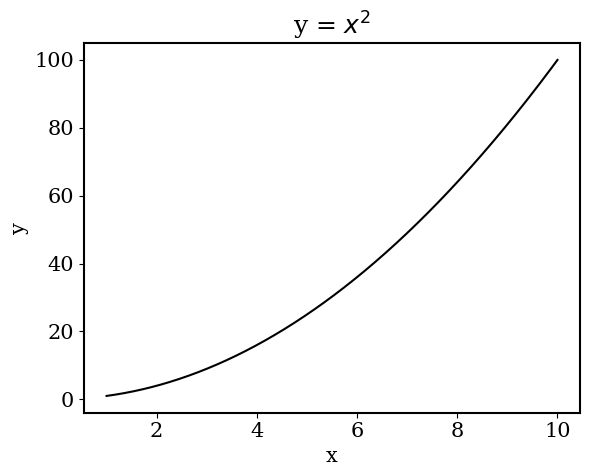

In [139]:
x_axis = np.linspace(1, 10, 1000)
y_squared = Power3(x_axis, 2)

fig, ax = plt.subplots()
ax.plot(x_axis, y_squared, color = 'black')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(r'y = $x^2$')
plt.show()

f) Create a function, PlotPower(), that allows you to create a plot
of x against x**a for a fixed a and a sequence of values of x. For
instance, if you call

In [133]:
def PlotPower(xrange, power, logy = False, logx = False):

    y = Power3(xrange, power)

    fig, ax = plt.subplots()
    ax.plot(xrange, y, color = 'black')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    ax.set_title(fr'y = $x^{power}$')
    
    if logy:
        ax.set_yscale('log')

    if logx:
        ax.set_xscale('log')

    plt.show()

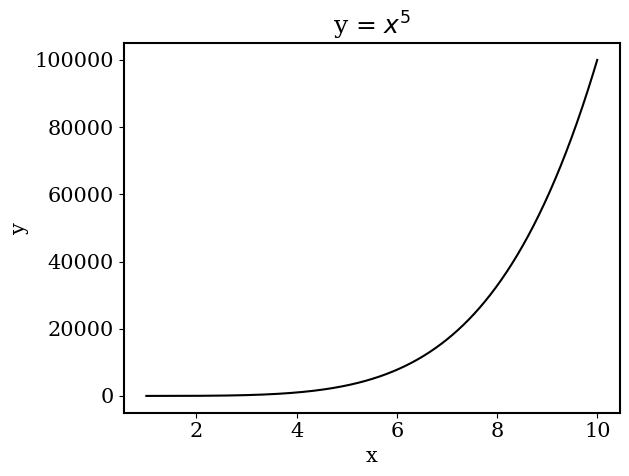

In [140]:
PlotPower(np.linspace(1, 10, 1000), 5)